In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/StudentsPerformance_cleaned.csv")

df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
X = df.drop("math_score", axis=1)

y = df["math_score"]

In [4]:
categorical_features = X.select_dtypes(include="str").columns

numerical_features = X.select_dtypes(exclude="str").columns

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(),

    "Lasso": Lasso(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42)

}

In [8]:
# Create a list to store model evaluation results
results = []

for name, model in models.items():

    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predict on test data
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store results
    results.append([name, r2, mae, mse, rmse])

In [9]:
# Create DataFrame for comparison
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "MSE",
        "RMSE"
    ]
)

# Sort models by R2 Score
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print(results_df)


               Model  R2 Score       MAE        MSE      RMSE
0              Ridge  0.880592  4.211113  29.056602  5.390418
1  Linear Regression  0.880433  4.214763  29.095170  5.393994
2  Gradient Boosting  0.872207  4.303784  31.097058  5.576474
3           AdaBoost  0.851649  4.681343  36.099407  6.008278
4      Random Forest  0.850393  4.701467  36.405085  6.033663
5              Lasso  0.825447  5.155701  42.475567  6.517328
6      Decision Tree  0.747348  6.240000  61.480000  7.840918


In [10]:
results_df.style.background_gradient(
    cmap="Blues",
    subset=["R2 Score"]
).format({
    "R2 Score": "{:.4f}",
    "MAE": "{:.4f}",
    "MSE": "{:.4f}",
    "RMSE": "{:.4f}"
})

,Model,R2 Score,MAE,MSE,RMSE
0,Ridge,0.8806,4.2111,29.0566,5.3904
1,Linear Regression,0.8804,4.2148,29.0952,5.3940
2,Gradient Boosting,0.8722,4.3038,31.0971,5.5765
3,AdaBoost,0.8516,4.6813,36.0994,6.0083
4,Random Forest,0.8504,4.7015,36.4051,6.0337
5,Lasso,0.8254,5.1557,42.4756,6.5173
6,Decision Tree,0.7473,6.2400,61.4800,7.8409


In [12]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [13]:
y_pred = final_model.predict(X_test)

In [14]:
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.8805917946912825
MAE      : 4.211112826071163
MSE      : 29.056601626694817
RMSE     : 5.390417574427311


In [15]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred,2)
})

prediction_df.head(10)

,Actual,Predicted
0,91,76.40
1,53,58.84
2,80,76.99
3,74,76.81
4,84,87.61
5,81,78.92
6,69,64.71
7,54,53.04
8,87,74.12
9,51,49.37


In [17]:
import pickle

with open("../model/ridge_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully!")

Model saved successfully!


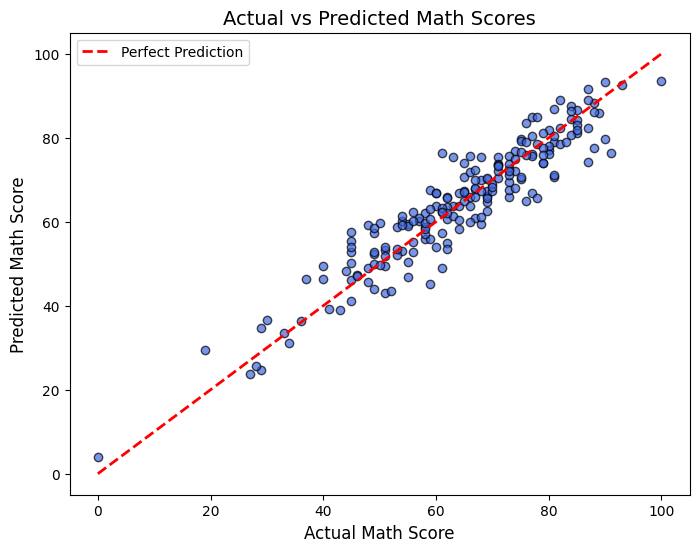

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color="royalblue",
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Math Scores", fontsize=14)
plt.xlabel("Actual Math Score", fontsize=12)
plt.ylabel("Predicted Math Score", fontsize=12)
plt.legend()

plt.show()

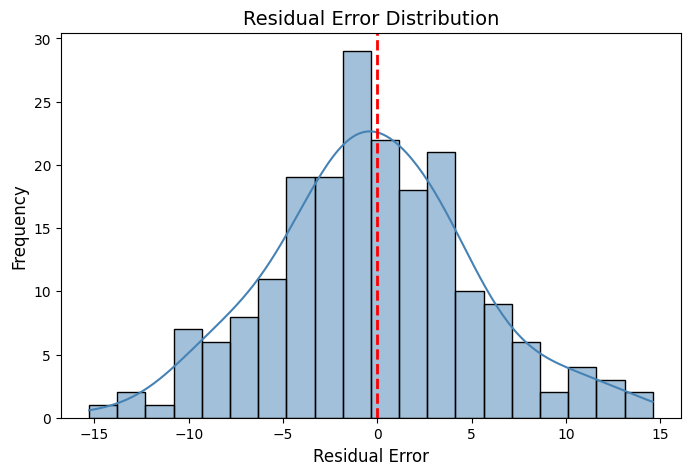

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=20,
    kde=True,
    color="steelblue"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Residual Error Distribution", fontsize=14)
plt.xlabel("Residual Error", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()
